# E-Commerce Sales & Customer Analytics — Complete Analyst Workflow

**Purpose:** Take the existing e-commerce data-quality/integrity work and continue it into a portfolio-ready business analysis.

**Workflow:** Data loading → quality audit → cleaning → relationship checks → financial validation → KPI overview → sales & profit → product performance → customers → discounts → delivery/returns → RFM → business insights.

# 1. The dataset — four tables, one business

Real e-commerce data never lives in one flat file. This dataset mirrors that:

| file | grain | rows |
|---|---|---|
| `ecommerce_sales_customer_analytics_150k.csv` | one **order** | ~|
| `order_items.csv` | one **product line within an order** | ~398k |
| `product_catalog.csv` | one **product** | ~1.2k |
| `customer_master.csv` | one **customer** | 25k |

Knowing the *grain* (what one row means) of every table before touching it prevents 90% of double-counting bugs.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
customer = pd.read_csv(r"D:\D_download\e commerce datasheet\customer_master.csv")
staticts = pd.read_csv(r"D:\D_download\e commerce datasheet\dataset_statistics.csv")
product = pd.read_csv(r"D:\D_download\e commerce datasheet\product_catalog.csv")
ecommerce = pd.read_csv(r"D:\D_download\e commerce datasheet\ecommerce_sales_customer_analytics_150k.csv")
order = pd.read_csv(r"D:\D_download\e commerce datasheet\order_items.csv")

print('customer =' ,customer.shape)
print('staticts =' ,staticts.shape)
print('product =' ,product.shape)
print('ecommerce =' ,ecommerce.shape)
print('order =' ,order.shape)

customer = (25000, 11)
staticts = (1, 11)
product = (1175, 9)
ecommerce = (138116, 46)
order = (397569, 12)


In [13]:
audit = []

tables = {
    "customer": customer,
    "statistics": staticts,
    "product": product,
    "ecommerce": ecommerce,
    "order": order
}

for name, df in tables.items():
    audit.append({
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": df.duplicated().sum(),
        "total_nulls": int(df.isna().sum().sum())
    })

display(pd.DataFrame(audit))

,table,rows,columns,duplicate_rows,total_nulls
0,customer,25000,11,0,0
1,statistics,1,11,0,0
2,product,1175,9,0,0
3,ecommerce,138116,46,0,573828
4,order,397569,12,0,0


In [17]:
tables = {
    "customer": customer,
    "statistics": staticts,
    "product": product,
    "ecommerce": ecommerce,
    "order": order
}

for name, df in tables.items():
    print(f"\n{name} =")
    print(", ".join(df.columns))


customer =
customer_id, customer_name, customer_age, gender, customer_segment, customer_city, customer_state, customer_country, region, customer_postal_code, customer_acquisition_cost

statistics =
Total Transactions, Total Columns, Total Customers, Total Products Used, Date Range, Total Revenue, Total Profit, Average Order Value, Average Rating, Return Rate, Cancellation Rate

product =
product_id, product_name, product_category, product_subcategory, brand, supplier, unit_price, product_cost, product_rating

ecommerce =
order_id, order_date, order_time, order_status, sales_channel, customer_id, customer_name, customer_age, gender, customer_segment, customer_type, customer_city, customer_state, customer_country, region, customer_postal_code, payment_method, payment_status, currency, shipping_method, warehouse, delivery_days, estimated_delivery_days, delivery_status, return_status, return_reason, customer_rating, review_sentiment, customer_review, marketing_channel, campaign_name, coup

In [20]:
for name, df in tables.items():
    print(f"\n===== {name.upper()} =====")
    print(pd.DataFrame({
        "column": df.columns,
        "data_type": df.dtypes.astype(str).values
    }).to_string(index=False))


===== CUSTOMER =====
                   column data_type
              customer_id    object
            customer_name    object
             customer_age     int64
                   gender    object
         customer_segment    object
            customer_city    object
           customer_state    object
         customer_country    object
                   region    object
     customer_postal_code    string
customer_acquisition_cost   float64

===== STATISTICS =====
             column data_type
 Total Transactions     int64
      Total Columns     int64
    Total Customers     int64
Total Products Used     int64
         Date Range    object
      Total Revenue    object
       Total Profit    object
Average Order Value    object
     Average Rating   float64
        Return Rate    object
  Cancellation Rate    object

===== PRODUCT =====
             column data_type
         product_id    object
       product_name    object
   product_category    object
product_subcategory  

In [22]:
# 1. Postal codes → string

customer["customer_postal_code"] = customer["customer_postal_code"].astype("string")
ecommerce["customer_postal_code"] = ecommerce["customer_postal_code"].astype("string")

print("1. Postal code conversion completed.")

1. Postal code conversion completed.


In [23]:
# 2. Order date → datetime

ecommerce["order_date"] = pd.to_datetime(
    ecommerce["order_date"],
    errors="coerce"
)

print("2. Order date conversion completed.")

2. Order date conversion completed.


In [24]:
# 3. Order time → hour

ecommerce["order_time_parsed"] = pd.to_datetime(
    ecommerce["order_time"].astype("string"),
    format="%H:%M:%S",
    errors="coerce"
)

ecommerce["order_hour"] = ecommerce["order_time_parsed"].dt.hour

print("3. Order time conversion completed.")

3. Order time conversion completed.


In [25]:
# 4. Fill structural nulls

ecommerce["return_status"] = ecommerce["return_status"].fillna("Not Returned")
ecommerce["return_reason"] = ecommerce["return_reason"].fillna("No Return")
ecommerce["campaign_name"] = ecommerce["campaign_name"].fillna("No Campaign")
ecommerce["coupon_code"] = ecommerce["coupon_code"].fillna("No Coupon")

print("4. Structural null handling completed.")

4. Structural null handling completed.


In [26]:
# 5. Calendar features

ecommerce["order_year"] = ecommerce["order_date"].dt.year
ecommerce["order_month"] = ecommerce["order_date"].dt.month
ecommerce["month_name"] = ecommerce["order_date"].dt.strftime("%b")
ecommerce["quarter"] = ecommerce["order_date"].dt.to_period("Q").astype("string")
ecommerce["day_of_week"] = ecommerce["order_date"].dt.day_name()

print("5. Calendar features completed.")

5. Calendar features completed.


In [27]:
# 6. Delivery performance

ecommerce["delivery_delay_days"] = (
    ecommerce["delivery_days"] - ecommerce["estimated_delivery_days"]
)

print("6. Delivery delay calculation completed.")

6. Delivery delay calculation completed.


In [28]:
# 7. Customer age groups

ecommerce["age_group"] = pd.cut(
    ecommerce["customer_age"],
    bins=[17, 24, 34, 44, 54, 64, 74],
    labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65-74"]
)

print("7. Age group creation completed.")

7. Age group creation completed.


In [29]:
# 8. Calculate discount percentage

ecommerce["discount_percentage_calc"] = np.where(
    ecommerce["gross_sales"].ne(0),
    (ecommerce["discount_amount"] / ecommerce["gross_sales"]) * 100,
    np.nan
)

print("8. Discount percentage calculation completed.")

8. Discount percentage calculation completed.


In [30]:
# 9. Final preparation check

print("9. All cleaning and feature preparation completed.")

9. All cleaning and feature preparation completed.


In [31]:
# FINAL DATA QUALITY CHECK

tables = {
    "customer": customer,
    "statistics": staticts,
    "product": product,
    "ecommerce": ecommerce,
    "order": order
}

# 1. Duplicate rows
print("\n========== 1. DUPLICATES ==========")

for name, df in tables.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")


# 2. Missing values
print("\n========== 2. MISSING VALUES ==========")

for name, df in tables.items():
    nulls = df.isna().sum()
    nulls = nulls[nulls > 0]

    print(f"\n{name}:")
    if len(nulls) == 0:
        print("No missing values")
    else:
        print(nulls)


# 3. Data types
print("\n========== 3. DATA TYPES ==========")

for name, df in tables.items():
    print(f"\n{name}:")
    print(df.dtypes)


# 4. Unique values / possible categorical problems
print("\n========== 4. CATEGORICAL CHECK ==========")

for name, df in tables.items():
    print(f"\n===== {name} =====")

    for col in df.select_dtypes(include=["object", "string", "category"]).columns:
        print(f"\n{col}:")
        print(df[col].dropna().unique()[:20])


# 5. Numeric ranges
print("\n========== 5. NUMERIC CHECK ==========")

for name, df in tables.items():
    print(f"\n===== {name} =====")
    print(df.select_dtypes(include="number").describe().T)


# 6. Date range
print("\n========== 6. DATE CHECK ==========")

print("Minimum order date:", ecommerce["order_date"].min())
print("Maximum order date:", ecommerce["order_date"].max())


# 7. Final row/column count
print("\n========== 7. FINAL TABLE SIZE ==========")

for name, df in tables.items():
    print(f"{name}: {df.shape[0]} rows × {df.shape[1]} columns")


print("\n========== CLEANING CHECK COMPLETED ==========")


========== 1. DUPLICATES ==========
customer: 0 duplicate rows
statistics: 0 duplicate rows
product: 0 duplicate rows
ecommerce: 0 duplicate rows
order: 0 duplicate rows

========== 2. MISSING VALUES ==========

customer:
No missing values

statistics:
No missing values

product:
No missing values

ecommerce:
delivery_days              24557
estimated_delivery_days    24557
customer_rating            24557
review_sentiment           24557
customer_review            24557
delivery_delay_days        24557
dtype: int64

order:
No missing values

========== 3. DATA TYPES ==========

customer:
customer_id                          object
customer_name                        object
customer_age                          int64
gender                               object
customer_segment                     object
customer_city                        object
customer_state                       object
customer_country                     object
region                               object
custome

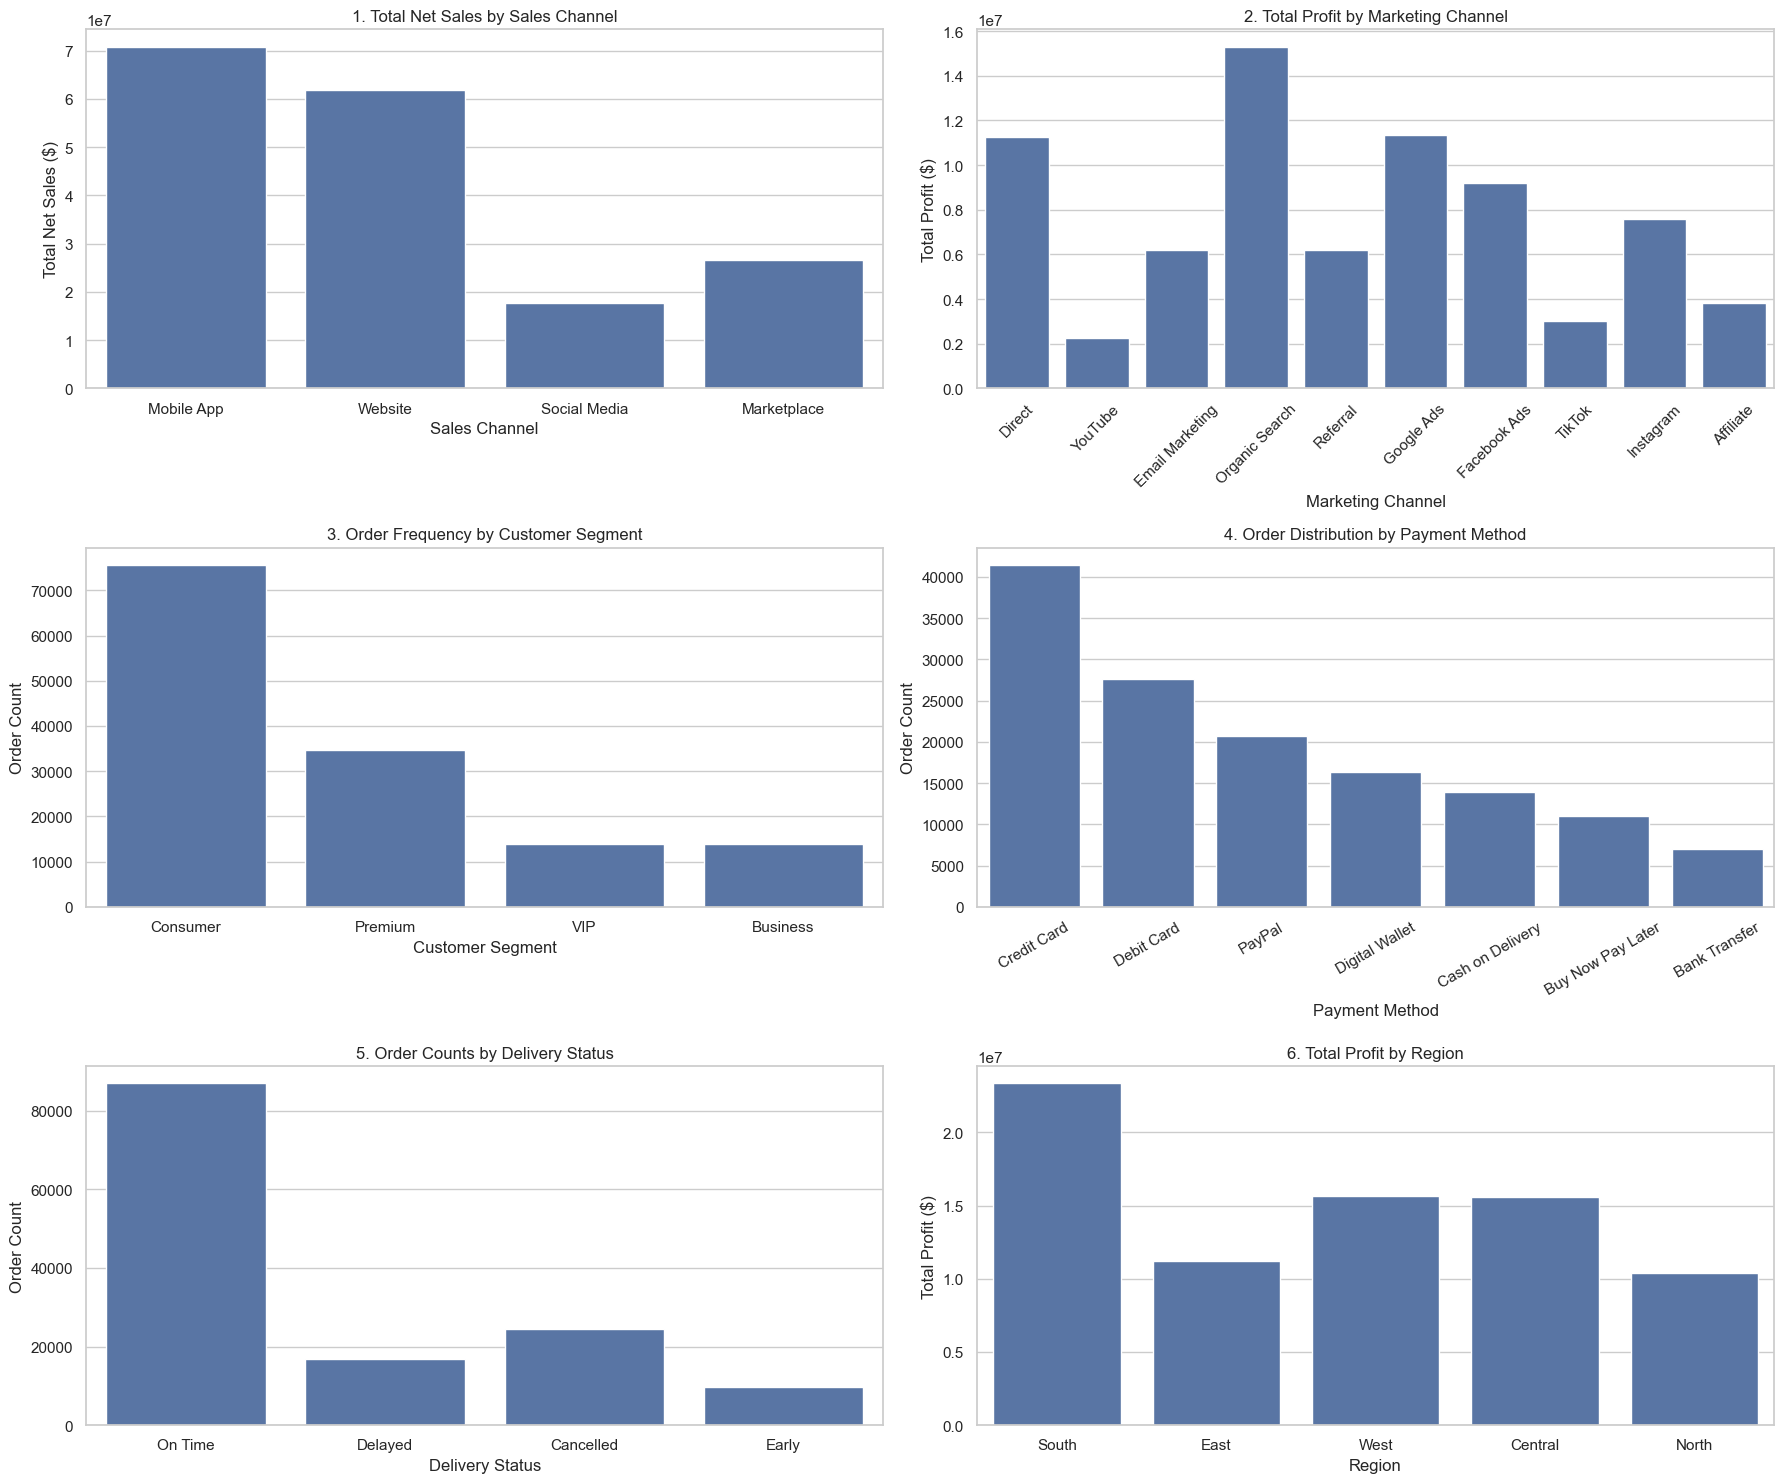

In [33]:
# ==========================================
# BARPLOTS & COUNTPLOTS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(18, 15))


# 1. Total Net Sales by Sales Channel
sns.barplot(
    data=ecommerce,
    x="sales_channel",
    y="net_sales",
    estimator=sum,
    ax=axes[0, 0],
    errorbar=None
)

axes[0, 0].set_title("1. Total Net Sales by Sales Channel")
axes[0, 0].set_ylabel("Total Net Sales ($)")
axes[0, 0].set_xlabel("Sales Channel")


# 2. Total Profit by Marketing Channel
sns.barplot(
    data=ecommerce,
    x="marketing_channel",
    y="profit",
    estimator=sum,
    ax=axes[0, 1],
    errorbar=None
)

axes[0, 1].set_title("2. Total Profit by Marketing Channel")
axes[0, 1].set_ylabel("Total Profit ($)")
axes[0, 1].set_xlabel("Marketing Channel")
axes[0, 1].tick_params(axis="x", rotation=45)


# 3. Order Frequency by Customer Segment
sns.countplot(
    data=ecommerce,
    x="customer_segment",
    ax=axes[1, 0]
)

axes[1, 0].set_title("3. Order Frequency by Customer Segment")
axes[1, 0].set_ylabel("Order Count")
axes[1, 0].set_xlabel("Customer Segment")


# 4. Order Distribution by Payment Method
sns.countplot(
    data=ecommerce,
    x="payment_method",
    order=ecommerce["payment_method"].value_counts().index,
    ax=axes[1, 1]
)

axes[1, 1].set_title("4. Order Distribution by Payment Method")
axes[1, 1].set_ylabel("Order Count")
axes[1, 1].set_xlabel("Payment Method")
axes[1, 1].tick_params(axis="x", rotation=30)


# 5. Order Counts by Delivery Status
sns.countplot(
    data=ecommerce,
    x="delivery_status",
    ax=axes[2, 0]
)

axes[2, 0].set_title("5. Order Counts by Delivery Status")
axes[2, 0].set_ylabel("Order Count")
axes[2, 0].set_xlabel("Delivery Status")


# 6. Total Profit by Region
sns.barplot(
    data=ecommerce,
    x="region",
    y="profit",
    estimator=sum,
    ax=axes[2, 1],
    errorbar=None
)

axes[2, 1].set_title("6. Total Profit by Region")
axes[2, 1].set_ylabel("Total Profit ($)")
axes[2, 1].set_xlabel("Region")


plt.tight_layout()
plt.show()

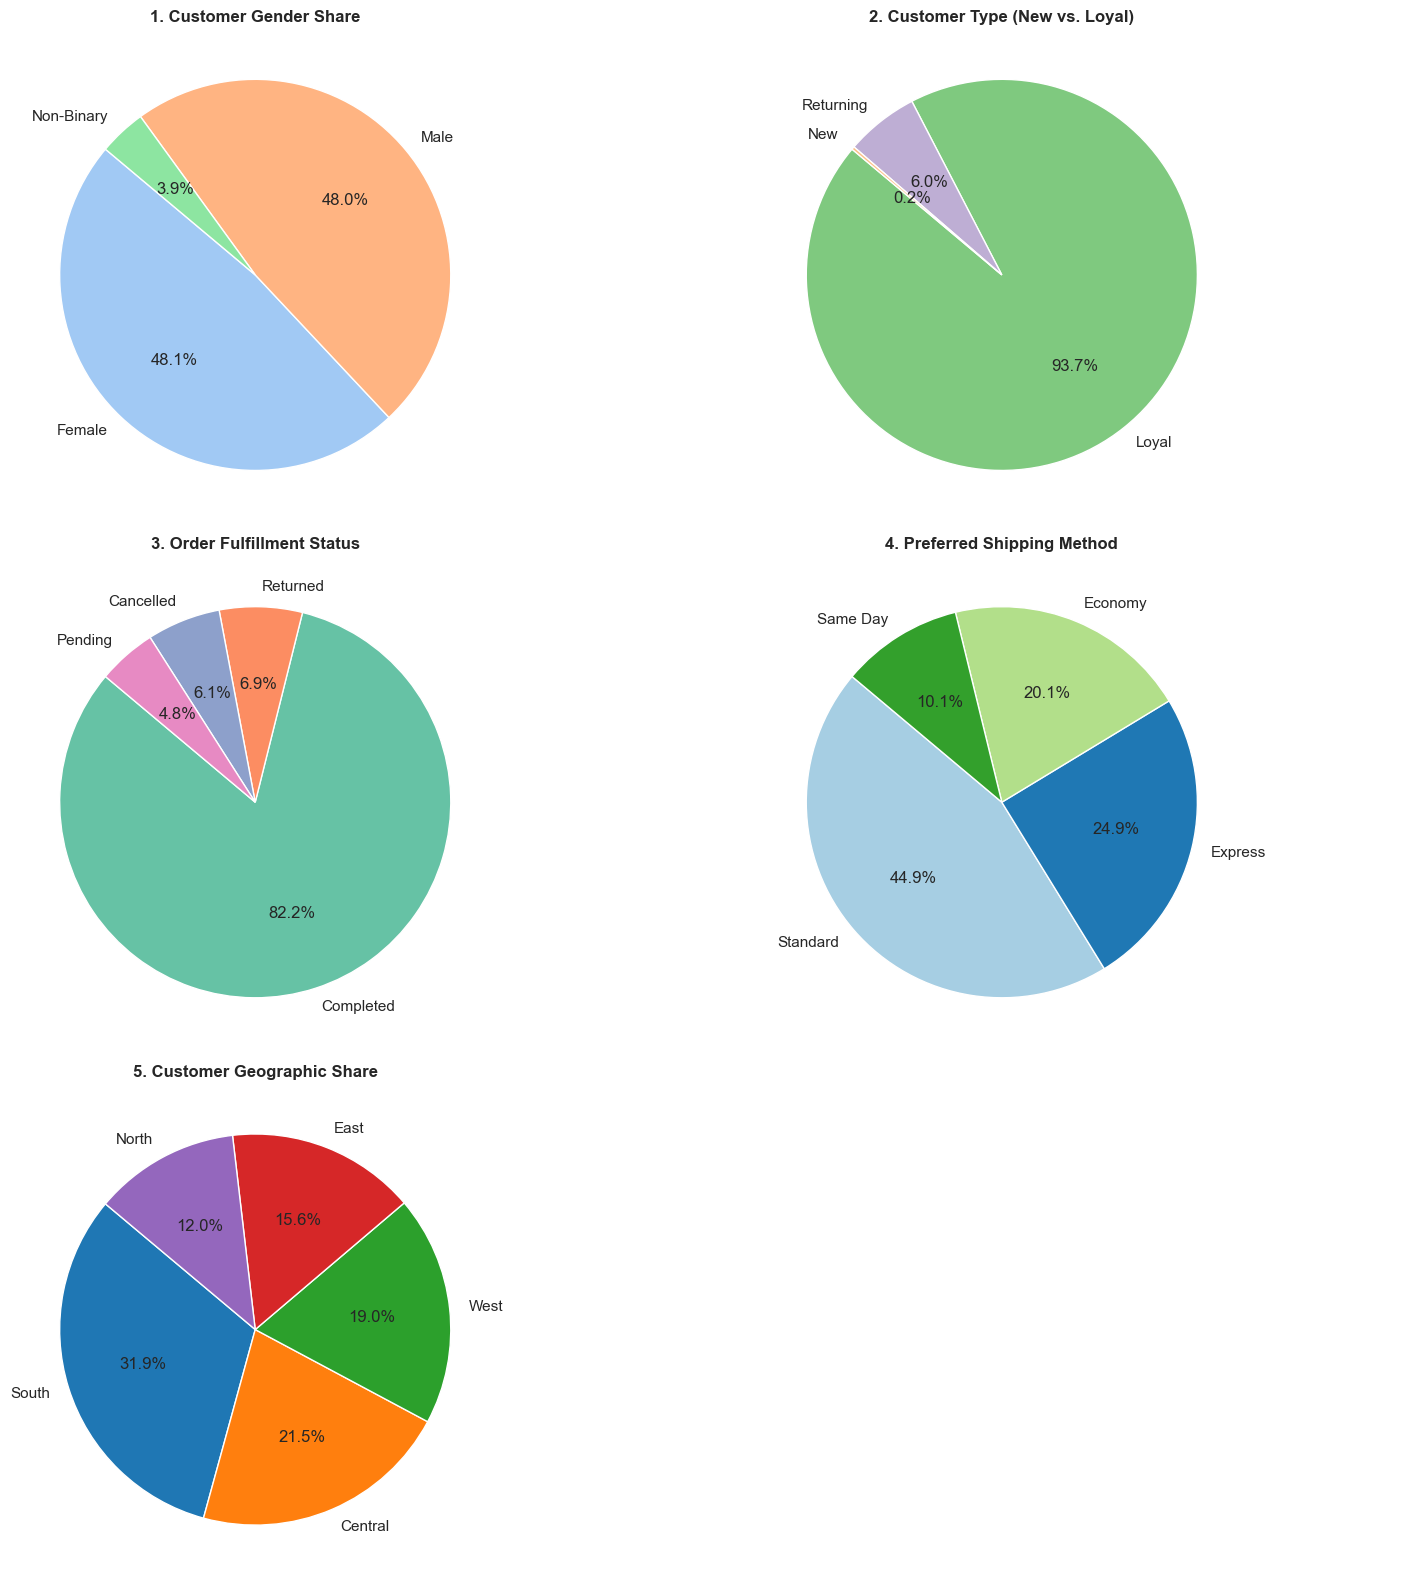

In [35]:
# ==========================================
# PIEPLOTS
# ==========================================

fig, axes = plt.subplots(3, 2, figsize=(16, 16))


# Helper function for pie plots
def draw_pie(data_col, title, ax, colors=None):
    counts = ecommerce[data_col].value_counts().dropna()

    ax.pie(
        counts,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=140,
        colors=sns.color_palette(colors or "Set3")
    )

    ax.set_title(title, fontsize=12, fontweight="bold")


# 1. Customer Gender Breakdown
draw_pie(
    "gender",
    "1. Customer Gender Share",
    axes[0, 0],
    "pastel"
)


# 2. Customer Type Proportion
draw_pie(
    "customer_type",
    "2. Customer Type (New vs. Loyal)",
    axes[0, 1],
    "Accent"
)


# 3. Order Status Distribution
draw_pie(
    "order_status",
    "3. Order Fulfillment Status",
    axes[1, 0],
    "Set2"
)


# 4. Shipping Method Proportion
draw_pie(
    "shipping_method",
    "4. Preferred Shipping Method",
    axes[1, 1],
    "Paired"
)


# 5. Customer Region Share
draw_pie(
    "region",
    "5. Customer Geographic Share",
    axes[2, 0],
    "tab10"
)


# Remove unused 6th plot
axes[2, 1].axis("off")


plt.tight_layout()
plt.show()

In [38]:
import os

# Create BI-ready folder
output_folder = "1_bi_ready"
os.makedirs(output_folder, exist_ok=True)

# Save all cleaned tables
customer.to_csv(
    os.path.join(output_folder, "customer.csv"),
    index=False
)

staticts.to_csv(
    os.path.join(output_folder, "statistics.csv"),
    index=False
)

product.to_csv(
    os.path.join(output_folder, "product.csv"),
    index=False
)

ecommerce.to_csv(
    os.path.join(output_folder, "ecommerce.csv"),
    index=False
)

order.to_csv(
    os.path.join(output_folder, "order.csv"),
    index=False
)

print("All BI-ready files saved successfully.")
print("Folder:", os.path.abspath(output_folder))

All BI-ready files saved successfully.
Folder: C:\Users\User\Desktop\python\1_bi_ready
